# TP ML entrainement d'un model sur des exercices sportifs
https://www.kaggle.com/datasets/valakhorasani/gym-members-exercise-dataset

---
## 0. Installation des dépendances

In [1]:
# Exécuter cette cellule une seule fois pour installer les packages
!pip install mlflow scikit-learn pandas numpy matplotlib seaborn kaggle xgboost lightgbm imbalanced-learn

     |████████████████████████████████| 24.7 MB 4.7 MB/s eta 0:00:0102
     |████████████████████████████████| 181 kB 17.9 MB/s eta 0:00:01
     |████████████████████████████████| 1.9 MB 8.6 MB/s eta 0:00:01
     |████████████████████████████████| 1.6 MB 16.9 MB/s eta 0:00:01
     |████████████████████████████████| 258 kB 11.1 MB/s eta 0:00:01
     |████████████████████████████████| 30.8 MB 34.5 MB/s eta 0:00:01
     |████████████████████████████████| 103 kB 14.9 MB/s eta 0:00:01
     |████████████████████████████████| 2.2 MB 27.3 MB/s eta 0:00:01
     |████████████████████████████████| 147 kB 18.1 MB/s eta 0:00:01
     |████████████████████████████████| 114 kB 19.3 MB/s eta 0:00:01
     |████████████████████████████████| 1.9 MB 13.4 MB/s eta 0:00:01
     |████████████████████████████████| 85 kB 10.2 MB/s eta 0:00:01
     |████████████████████████████████| 247 kB 17.6 MB/s eta 0:00:01
  Using cached packaging-25.0-py3-none-any.whl (66 kB)
     |████████████████████████████████| 69 kB 7

In [ ]:
import os

os.makedirs('data', exist_ok=True)
os.makedirs('models', exist_ok=True)

# Vérifier que le fichier est présent
data_files = os.listdir('data')
print('Fichiers dans data/ :', data_files)

Fichiers dans data/ : ['gym_members_exercise_tracking.csv']


---
## 1. Imports

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, learning_curve
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Modèles
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
import lightgbm as lgb

# Métriques
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# MLflow
import mlflow
import mlflow.sklearn

import joblib

# Style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)

print('Tous les imports sont OK !')

Tous les imports sont OK !


---
## 2. Chargement des données

In [4]:
# Adapter le chemin si nécessaire
CSV_PATH = 'data/gym_members_exercise_tracking.csv'

df = pd.read_csv(CSV_PATH)

print(f'Shape : {df.shape}')
df.head()

Shape : (973, 15)


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


---
## 3. EDA — Exploratory Data Analysis

### 3.1 Vue d'ensemble

In [5]:
print('=== Types de colonnes ===')
print(df.dtypes)
print('\n=== Statistiques descriptives ===')
df.describe(include='all')

=== Types de colonnes ===
Age                                int64
Gender                            object
Weight (kg)                      float64
Height (m)                       float64
Max_BPM                            int64
Avg_BPM                            int64
Resting_BPM                        int64
Session_Duration (hours)         float64
Calories_Burned                  float64
Workout_Type                      object
Fat_Percentage                   float64
Water_Intake (liters)            float64
Workout_Frequency (days/week)      int64
Experience_Level                   int64
BMI                              float64
dtype: object

=== Statistiques descriptives ===


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
count,973.000000,973,973.000000,973.00000,973.000000,973.000000,973.000000,973.000000,973.000000,973,973.000000,973.000000,973.000000,973.000000,973.000000
unique,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN
top,NaN,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Strength,NaN,NaN,NaN,NaN,NaN
freq,NaN,511,NaN,NaN,NaN,NaN,NaN,NaN,NaN,258,NaN,NaN,NaN,NaN,NaN
mean,38.683453,NaN,73.854676,1.72258,179.883864,143.766701,62.223022,1.256423,905.422405,NaN,24.976773,2.626619,3.321686,1.809866,24.912127
std,12.180928,NaN,21.207500,0.12772,11.525686,14.345101,7.327060,0.343033,272.641516,NaN,6.259419,0.600172,0.913047,0.739693,6.660879
min,18.000000,NaN,40.000000,1.50000,160.000000,120.000000,50.000000,0.500000,303.000000,NaN,10.000000,1.500000,2.000000,1.000000,12.320000
25%,28.000000,NaN,58.100000,1.62000,170.000000,131.000000,56.000000,1.040000,720.000000,NaN,21.300000,2.200000,3.000000,1.000000,20.110000
50%,40.000000,NaN,70.000000,1.71000,180.000000,143.000000,62.000000,1.260000,893.000000,NaN,26.200000,2.600000,3.000000,2.000000,24.160000
75%,49.000000,NaN,86.000000,1.80000,190.000000,156.000000,68.000000,1.460000,1076.000000,NaN,29.300000,3.100000,4.000000,2.000000,28.560000


In [6]:
print('=== Valeurs manquantes ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'count': missing, 'pct': missing_pct})[missing > 0]

=== Valeurs manquantes ===


,count,pct


In [7]:
print('=== Doublons ===')
print(f'Nombre de lignes dupliquées : {df.duplicated().sum()}')

=== Doublons ===
Nombre de lignes dupliquées : 0


### 3.2 Distribution de la cible

FileNotFoundError: [Errno 2] No such file or directory: 'figures/target_distribution.png'

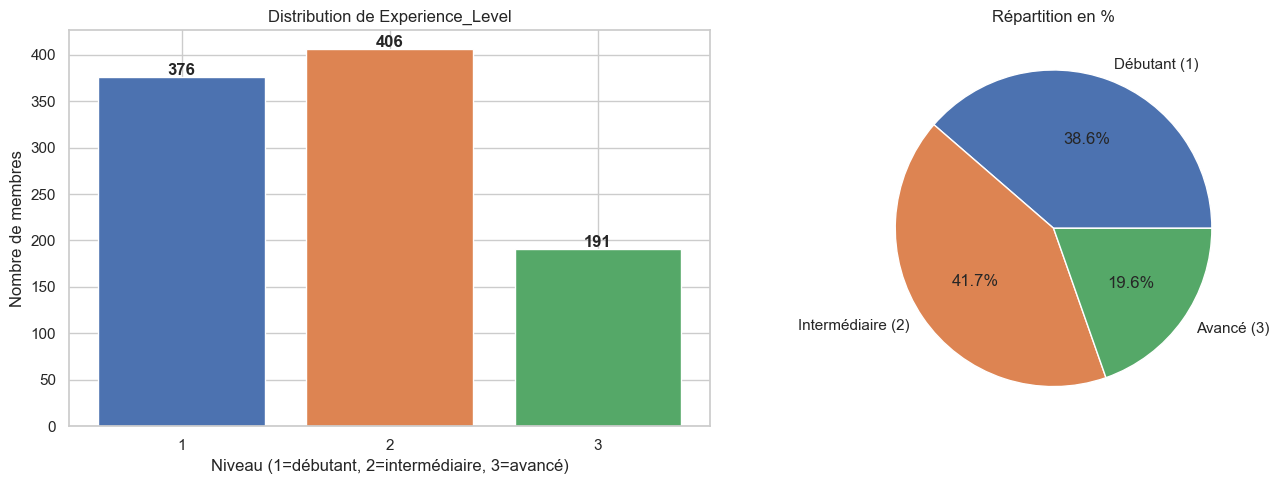

In [8]:
TARGET = 'Experience_Level'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

value_counts = df[TARGET].value_counts().sort_index()

axes[0].bar(value_counts.index.astype(str), value_counts.values, color=['#4C72B0','#DD8452','#55A868'])
axes[0].set_title('Distribution de Experience_Level')
axes[0].set_xlabel('Niveau (1=débutant, 2=intermédiaire, 3=avancé)')
axes[0].set_ylabel('Nombre de membres')
for i, v in enumerate(value_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

axes[1].pie(value_counts.values, labels=['Débutant (1)','Intermédiaire (2)','Avancé (3)'],
            autopct='%1.1f%%', colors=['#4C72B0','#DD8452','#55A868'])
axes[1].set_title('Répartition en %')

plt.tight_layout()
plt.savefig('figures/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Distribution des variables numériques

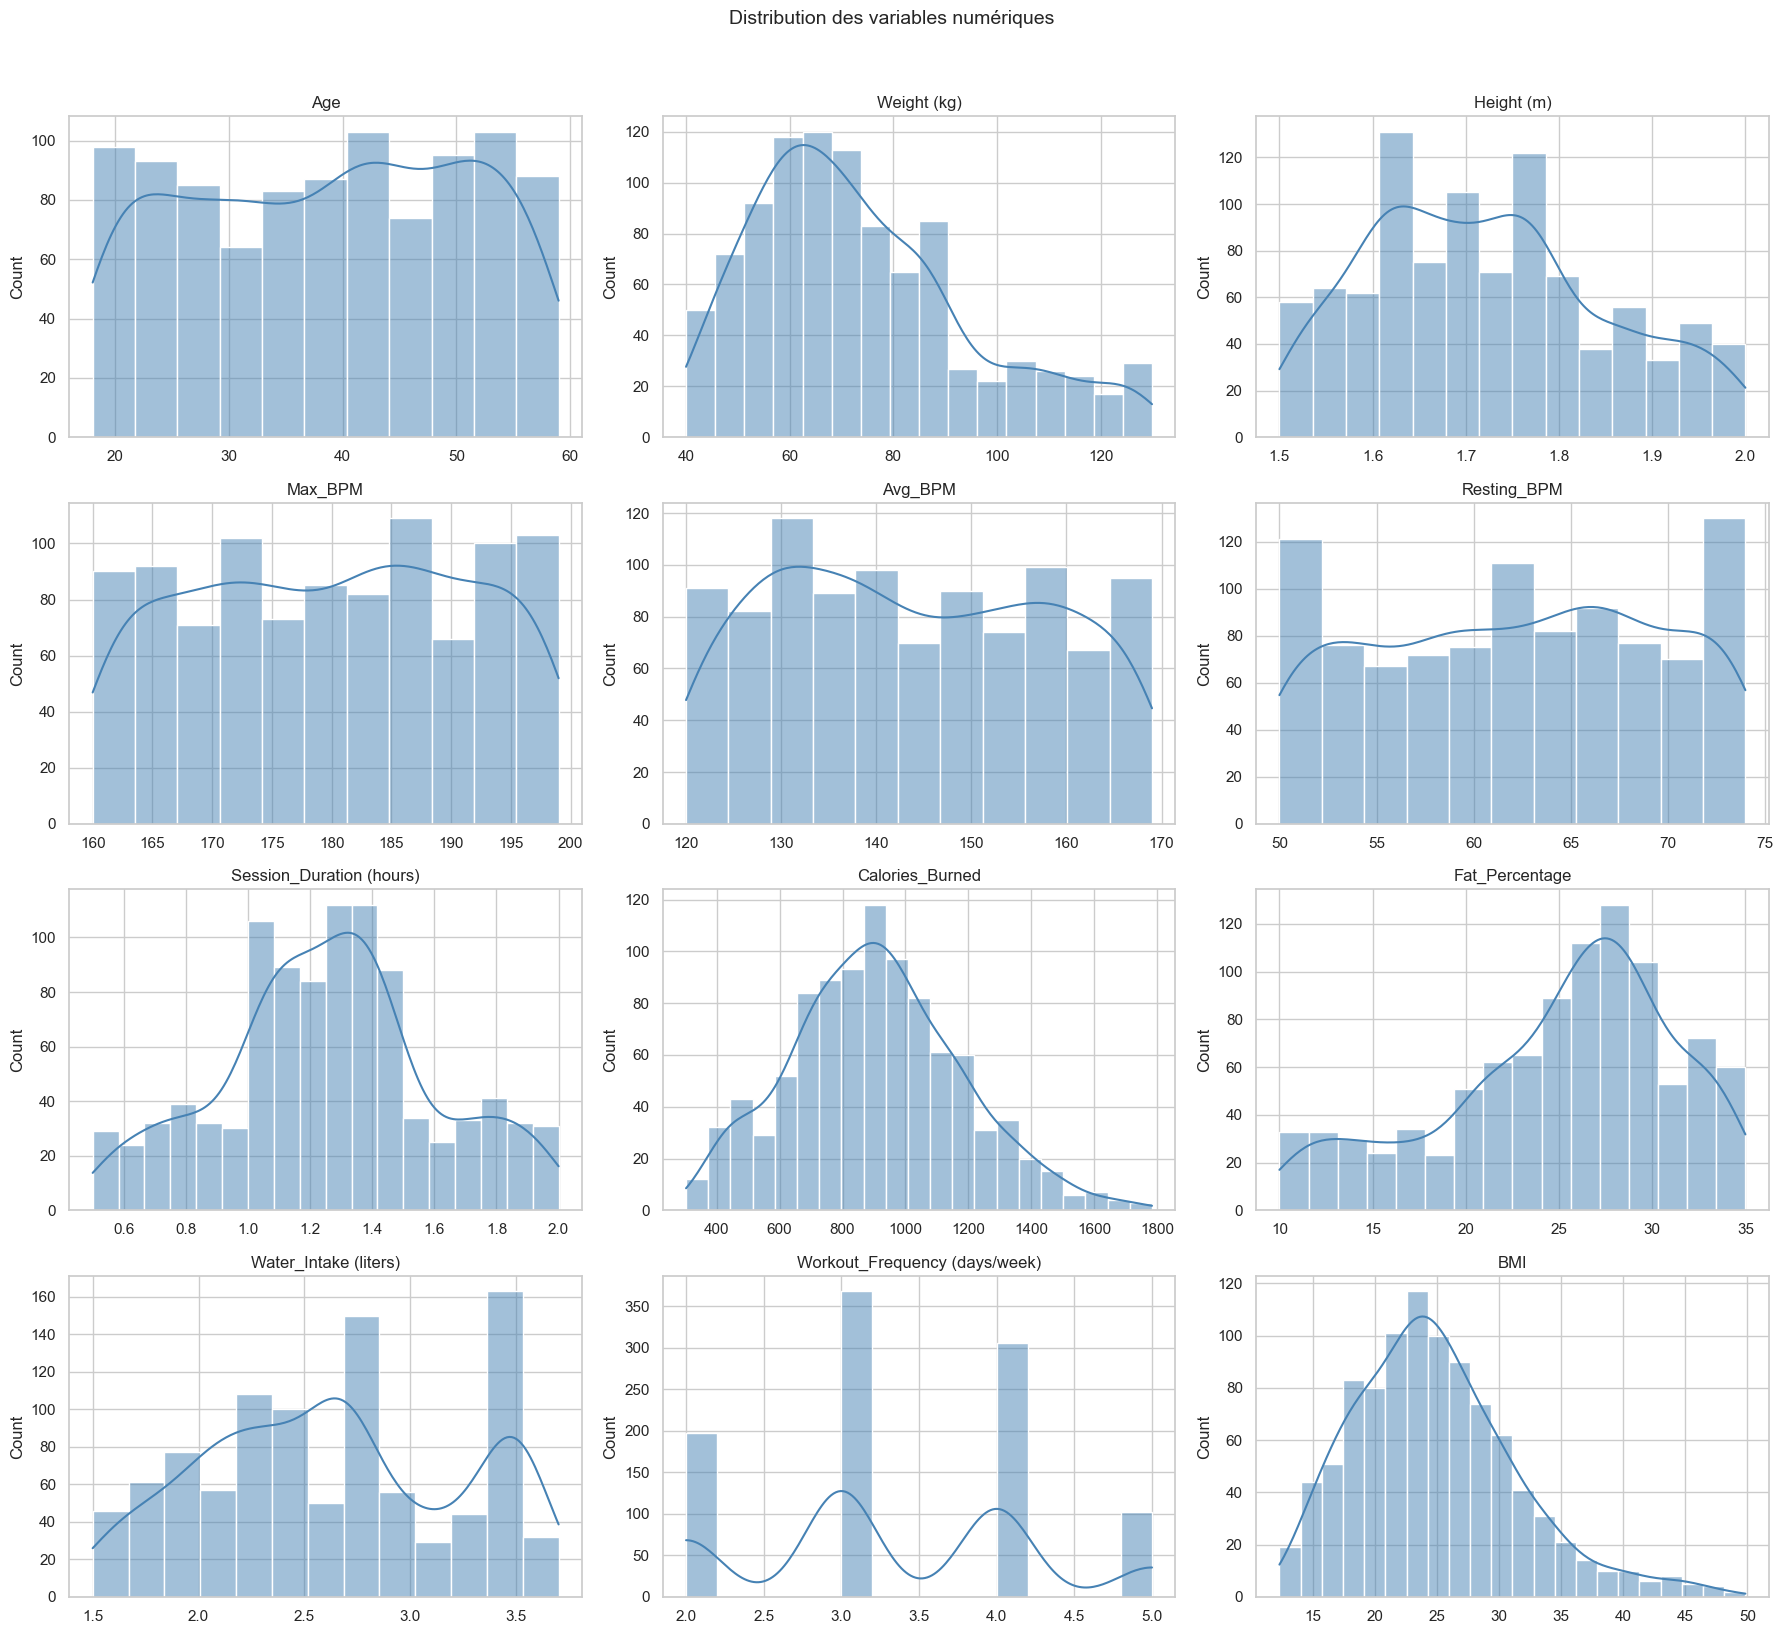

In [9]:
os.makedirs('figures', exist_ok=True)

num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c != TARGET]

n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], ax=axes[i], kde=True, color='steelblue')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution des variables numériques', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('figures/num_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 Boxplots par niveau d'expérience

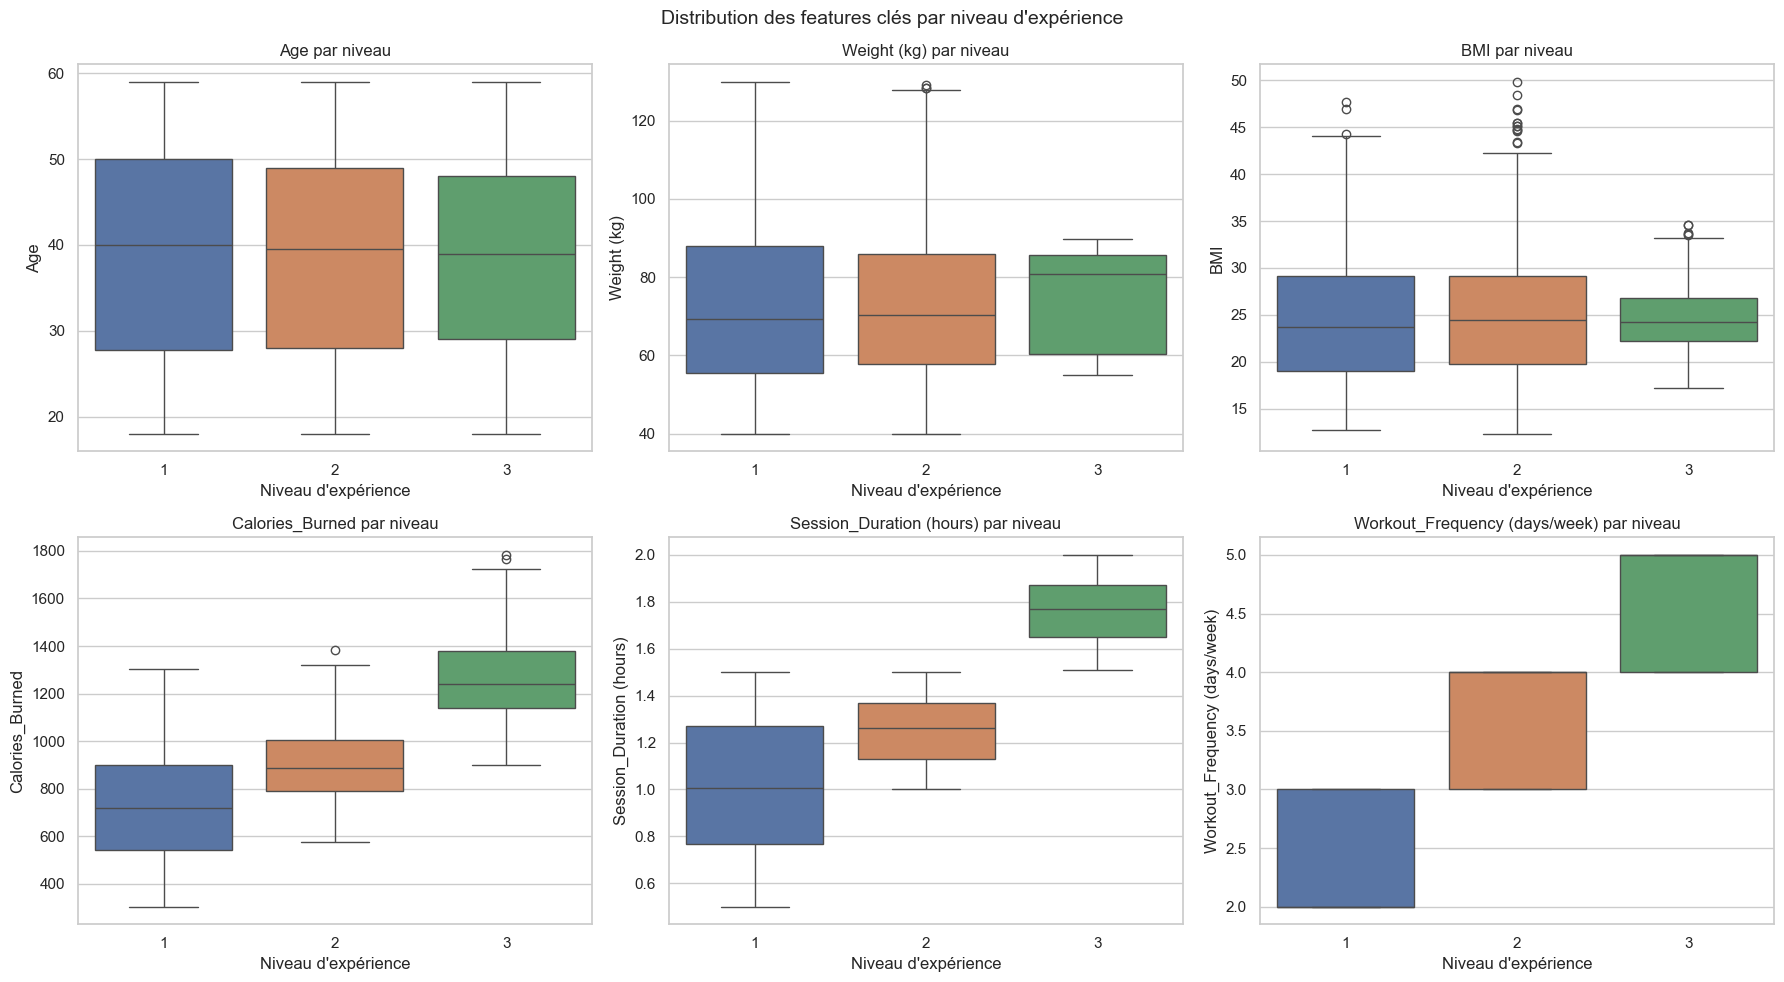

In [10]:
key_features = ['Age', 'Weight (kg)', 'BMI', 'Calories_Burned', 
                'Session_Duration (hours)', 'Workout_Frequency (days/week)']
key_features = [f for f in key_features if f in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(key_features[:6]):
    sns.boxplot(data=df, x=TARGET, y=col, ax=axes[i],
                palette=['#4C72B0','#DD8452','#55A868'])
    axes[i].set_title(f'{col} par niveau')
    axes[i].set_xlabel('Niveau d\'expérience')

plt.suptitle('Distribution des features clés par niveau d\'expérience', fontsize=14)
plt.tight_layout()
plt.savefig('figures/boxplots_by_level.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.5 Matrice de corrélation

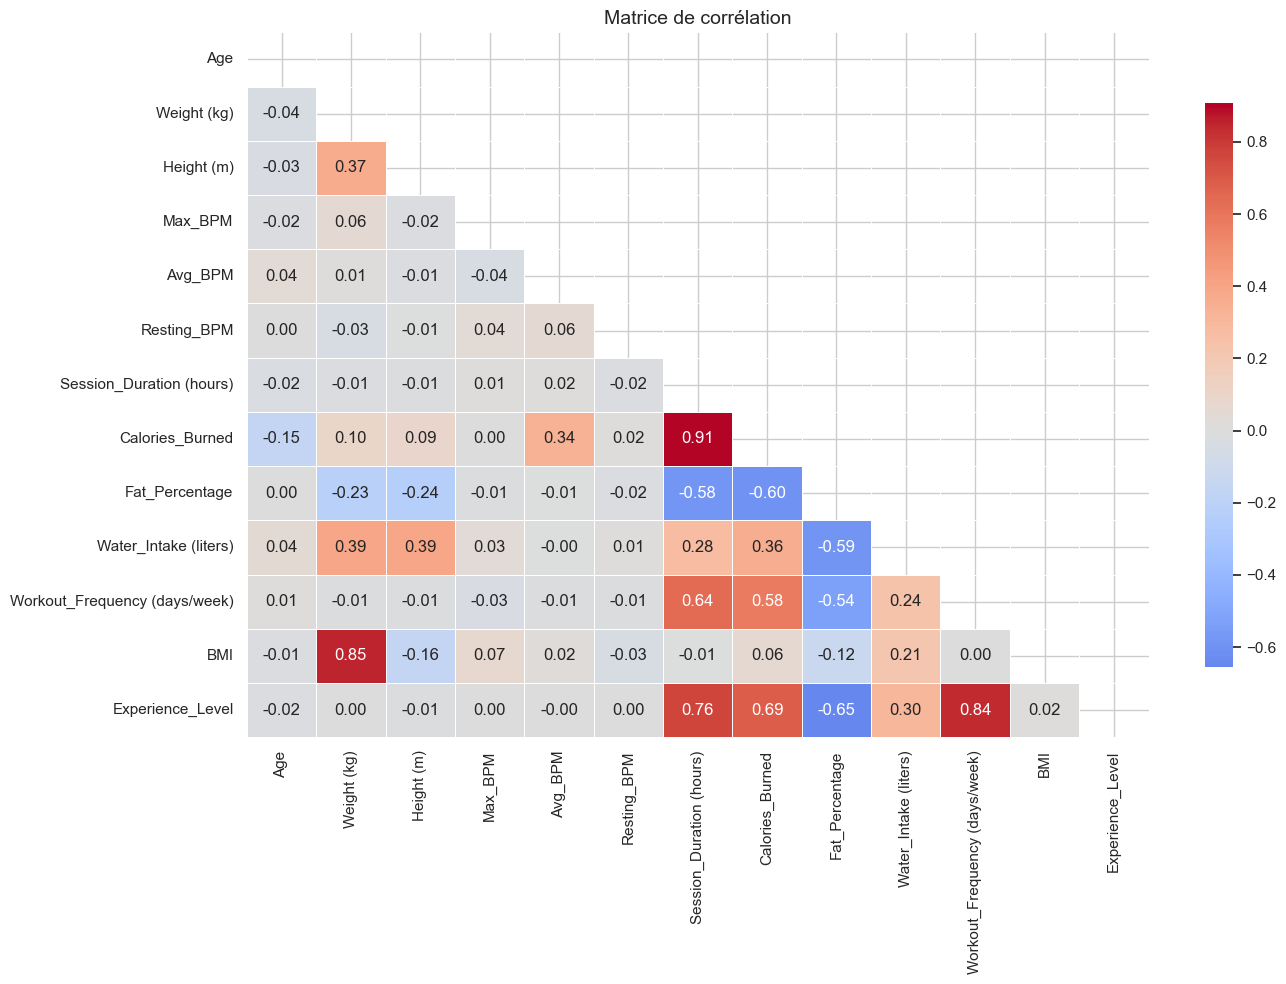

In [11]:
corr = df[num_cols + [TARGET]].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Matrice de corrélation', fontsize=14)
plt.tight_layout()
plt.savefig('figures/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.6 Variables catégorielles

Colonnes catégorielles : ['Gender', 'Workout_Type']


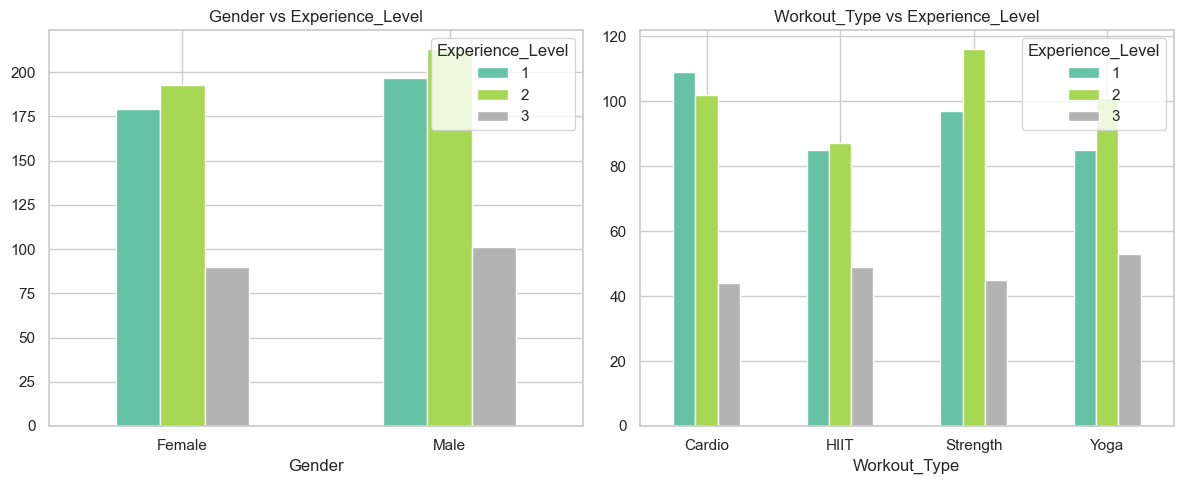

In [12]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print('Colonnes catégorielles :', cat_cols)

if cat_cols:
    fig, axes = plt.subplots(1, len(cat_cols), figsize=(6 * len(cat_cols), 5))
    if len(cat_cols) == 1:
        axes = [axes]
    for i, col in enumerate(cat_cols):
        counts = df.groupby([col, TARGET]).size().unstack(fill_value=0)
        counts.plot(kind='bar', ax=axes[i], colormap='Set2')
        axes[i].set_title(f'{col} vs {TARGET}')
        axes[i].set_xlabel(col)
        axes[i].tick_params(axis='x', rotation=0)
    plt.tight_layout()
    plt.savefig('figures/cat_features.png', dpi=150, bbox_inches='tight')
    plt.show()

### 3.7 Pairplot (features les plus corrélées avec la cible)

Top 5 features corrélées avec la cible : ['Workout_Frequency (days/week)', 'Session_Duration (hours)', 'Calories_Burned', 'Fat_Percentage', 'Water_Intake (liters)']


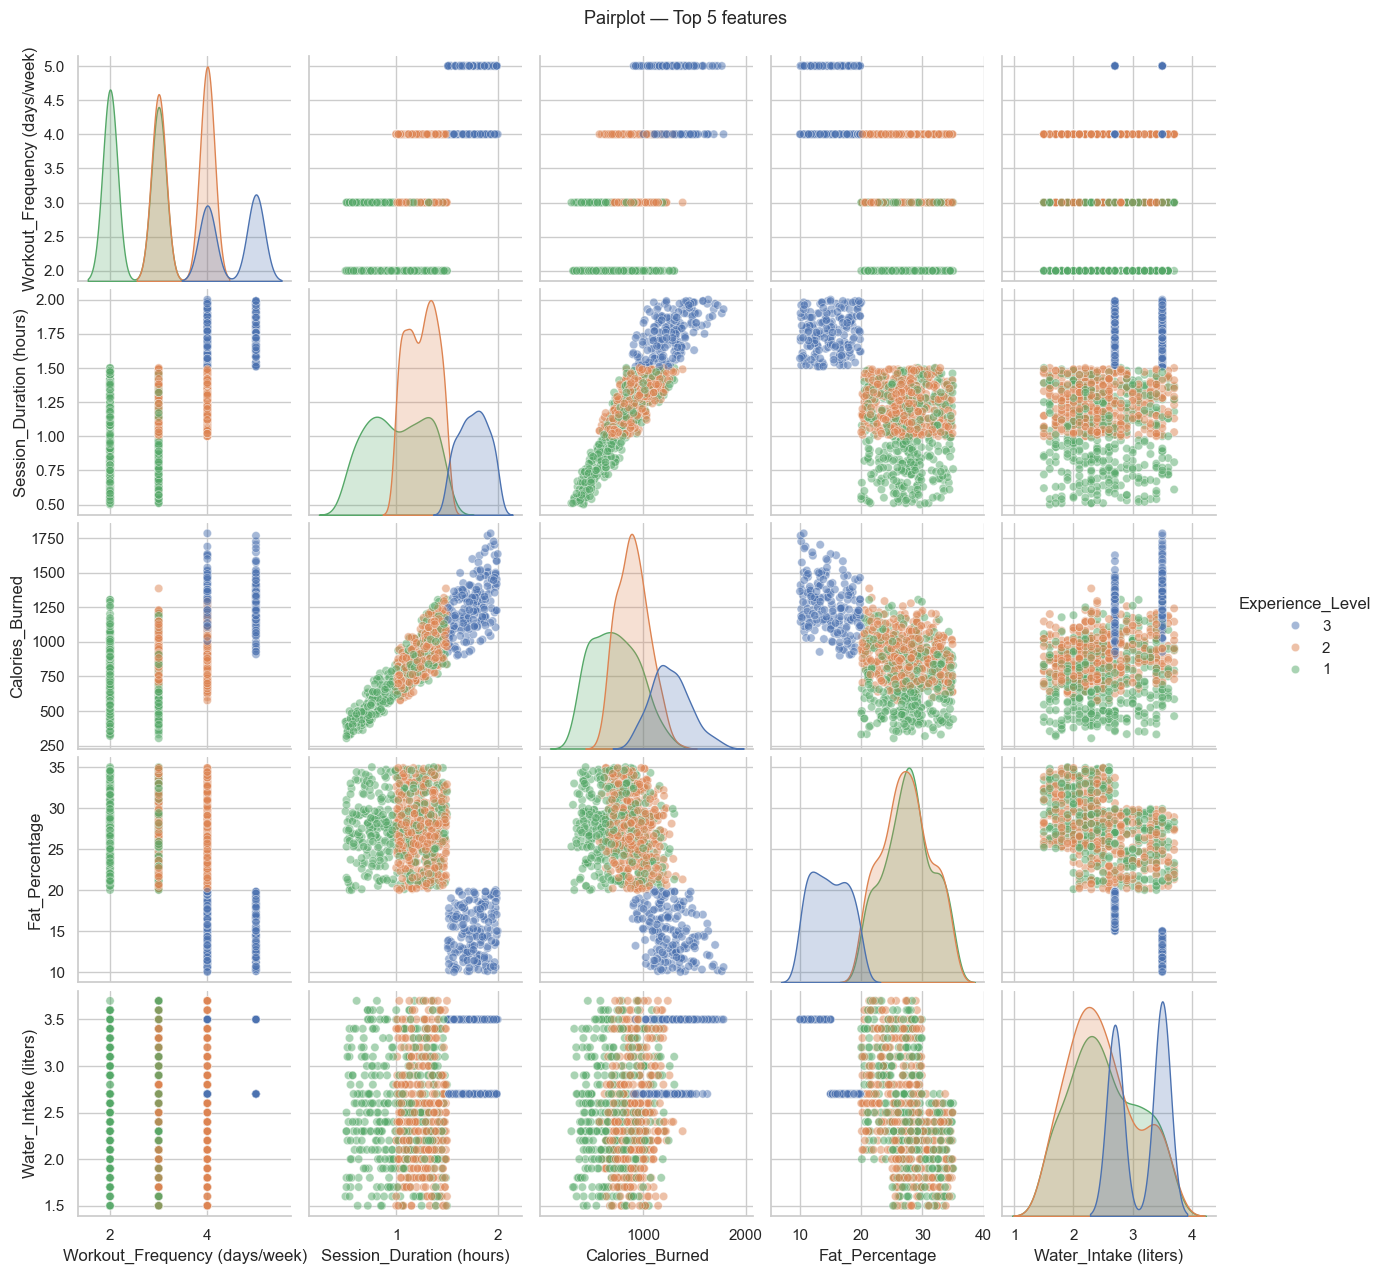

In [13]:
# Top 5 features corrélées avec la cible
top_features = corr[TARGET].abs().drop(TARGET).nlargest(5).index.tolist()
print('Top 5 features corrélées avec la cible :', top_features)

pairplot_df = df[top_features + [TARGET]].copy()
pairplot_df[TARGET] = pairplot_df[TARGET].astype(str)

pair_grid = sns.pairplot(pairplot_df, hue=TARGET, palette=['#4C72B0','#DD8452','#55A868'],
                          diag_kind='kde', plot_kws={'alpha': 0.5})
pair_grid.figure.suptitle('Pairplot — Top 5 features', y=1.02, fontsize=13)
plt.savefig('figures/pairplot.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 4. Nettoyage des données

In [14]:
df_clean = df.copy()

# 4.1 Suppression des doublons
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f'Doublons supprimés : {before - len(df_clean)}')

# 4.2 Valeurs aberrantes — méthode IQR sur les colonnes numériques
def remove_outliers_iqr(df, cols, factor=3.0):
    """Supprime les lignes où une valeur dépasse factor * IQR au-delà des quartiles."""
    mask = pd.Series([True] * len(df), index=df.index)
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - factor * IQR
        upper = Q3 + factor * IQR
        mask = mask & df[col].between(lower, upper)
    return df[mask]

before = len(df_clean)
df_clean = remove_outliers_iqr(df_clean, num_cols)
print(f'Lignes outliers supprimées (IQR x3) : {before - len(df_clean)}')

print(f'\nShape final : {df_clean.shape}')

Doublons supprimés : 0
Lignes outliers supprimées (IQR x3) : 0

Shape final : (973, 15)


In [15]:
# 4.3 Vérification des types et cohérence
print(df_clean.dtypes)
print('\nValeurs manquantes restantes :')
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Age                                int64
Gender                            object
Weight (kg)                      float64
Height (m)                       float64
Max_BPM                            int64
Avg_BPM                            int64
Resting_BPM                        int64
Session_Duration (hours)         float64
Calories_Burned                  float64
Workout_Type                      object
Fat_Percentage                   float64
Water_Intake (liters)            float64
Workout_Frequency (days/week)      int64
Experience_Level                   int64
BMI                              float64
dtype: object

Valeurs manquantes restantes :
Series([], dtype: int64)


---
## 5. Preprocessing

### 5.1 Séparation features / cible

In [16]:
X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET]

# Identifier les colonnes numériques et catégorielles
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

print(f'Features numériques ({len(numerical_features)}) : {numerical_features}')
print(f'Features catégorielles ({len(categorical_features)}) : {categorical_features}')
print(f'\nCible : {TARGET}')
print(f'Classes : {sorted(y.unique())}')

Features numériques (12) : ['Age', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'BMI']
Features catégorielles (2) : ['Gender', 'Workout_Type']

Cible : Experience_Level
Classes : [np.int64(1), np.int64(2), np.int64(3)]


In [17]:
# 5.2 Train / Test split (80/20, stratifié)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train : {X_train.shape[0]} lignes')
print(f'Test  : {X_test.shape[0]} lignes')
print('\nDistribution train :')
print(y_train.value_counts(normalize=True).round(3))
print('\nDistribution test :')
print(y_test.value_counts(normalize=True).round(3))

Train : 778 lignes
Test  : 195 lignes

Distribution train :
Experience_Level
2    0.416
1    0.387
3    0.197
Name: proportion, dtype: float64

Distribution test :
Experience_Level
2    0.421
1    0.385
3    0.195
Name: proportion, dtype: float64


In [18]:
# 5.3 Preprocessor avec ColumnTransformer
# Numérique : imputation (médiane) + standardisation
# Catégoriel : imputation (mode) + OneHot

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_features),
    ('cat', categorical_transformer, categorical_features)
])

print('Preprocessor créé :')
print(preprocessor)

Preprocessor créé :
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'Weight (kg)', 'Height (m)', 'Max_BPM',
                                  'Avg_BPM', 'Resting_BPM',
                                  'Session_Duration (hours)', 'Calories_Burned',
                                  'Fat_Percentage', 'Water_Intake (liters)',
                                  'Workout_Frequency (days/week)', 'BMI']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignor

---
## 6. Entraînement et comparaison de modèles

### 6.1 Baseline rapide (cross-validation)

In [19]:
# Dictionnaire de modèles à comparer
base_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42),
    'XGBoost':             xgb.XGBClassifier(eval_metric='mlogloss', random_state=42, verbosity=0),
    'LightGBM':            lgb.LGBMClassifier(random_state=42, verbose=-1),
    'SVM':                 SVC(probability=True, random_state=42),
    'KNN':                 KNeighborsClassifier()
}

results = []

for name, model in base_models.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    results.append({
        'Modèle': name,
        'CV Mean Acc': scores.mean().round(4),
        'CV Std': scores.std().round(4)
    })
    print(f'{name:25s} → {scores.mean():.4f} ± {scores.std():.4f}')

results_df = pd.DataFrame(results).sort_values('CV Mean Acc', ascending=False)
print('\n', results_df.to_string(index=False))

Logistic Regression       → 0.8676 ± 0.0123
Decision Tree             → 0.8496 ± 0.0055
Random Forest             → 0.8664 ± 0.0167
Gradient Boosting         → 0.8882 ± 0.0197


ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/victorboyadjian/Documents/dev/TP_API_IA/.venv/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/victorboyadjian/Documents/dev/TP_API_IA/.venv/lib/python3.9/site-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/Users/victorboyadjian/Documents/dev/TP_API_IA/.venv/lib/python3.9/site-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, **last_step_params["fit"])
  File "/Users/victorboyadjian/Documents/dev/TP_API_IA/.venv/lib/pytho

NameError: name 'results_df' is not defined

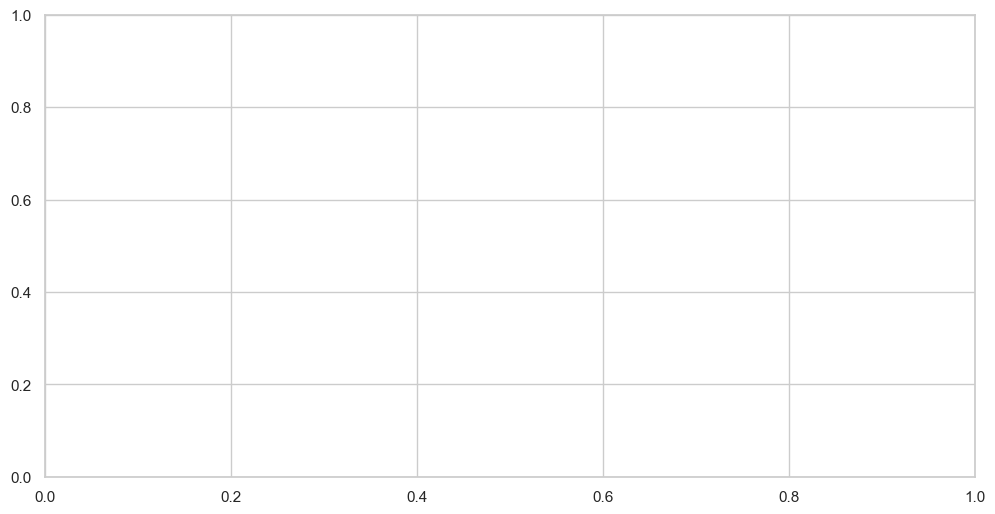

In [20]:
# Visualisation de la comparaison
fig, ax = plt.subplots(figsize=(12, 6))

colors = sns.color_palette('muted', len(results_df))
bars = ax.barh(results_df['Modèle'], results_df['CV Mean Acc'], xerr=results_df['CV Std'],
               color=colors, capsize=5, edgecolor='white')

for bar, val in zip(bars, results_df['CV Mean Acc']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontweight='bold')

ax.set_xlabel('Accuracy (CV 5-fold)')
ax.set_title('Comparaison des modèles — Cross-Validation')
ax.set_xlim(0, 1.05)
plt.tight_layout()
plt.savefig('figures/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Optimisation des hyperparamètres

On optimise les **2 meilleurs modèles** : en général Random Forest et XGBoost.

### 7.1 Random Forest — GridSearchCV

In [21]:
rf_pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    'clf__n_estimators':      [100, 200, 300],
    'clf__max_depth':         [None, 10, 20],
    'clf__min_samples_split': [2, 5, 10],
    'clf__max_features':      ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    refit=True
)

rf_grid.fit(X_train, y_train)

print('\nMeilleurs paramètres RF :', rf_grid.best_params_)
print(f'Meilleur score CV RF   : {rf_grid.best_score_:.4f}')

Fitting 5 folds for each of 54 candidates, totalling 270 fits

Meilleurs paramètres RF : {'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_split': 5, 'clf__n_estimators': 300}
Meilleur score CV RF   : 0.8856


### 7.2 XGBoost — RandomizedSearchCV

In [22]:
from scipy.stats import randint, uniform

xgb_pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', xgb.XGBClassifier(eval_metric='mlogloss', random_state=42, verbosity=0))
])

xgb_param_dist = {
    'clf__n_estimators':  randint(100, 500),
    'clf__max_depth':     randint(3, 10),
    'clf__learning_rate': uniform(0.01, 0.3),
    'clf__subsample':     uniform(0.6, 0.4),
    'clf__colsample_bytree': uniform(0.6, 0.4),
    'clf__gamma':         uniform(0, 0.5),
    'clf__reg_alpha':     uniform(0, 1),
    'clf__reg_lambda':    uniform(0.5, 2)
}

xgb_random = RandomizedSearchCV(
    xgb_pipeline,
    xgb_param_dist,
    n_iter=50,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    random_state=42,
    refit=True
)

xgb_random.fit(X_train, y_train)

print('\nMeilleurs paramètres XGB :', xgb_random.best_params_)
print(f'Meilleur score CV XGB    : {xgb_random.best_score_:.4f}')

Fitting 5 folds for each of 50 candidates, totalling 250 fits


ValueError: 
All the 250 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
250 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/victorboyadjian/Documents/dev/TP_API_IA/.venv/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/victorboyadjian/Documents/dev/TP_API_IA/.venv/lib/python3.9/site-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/Users/victorboyadjian/Documents/dev/TP_API_IA/.venv/lib/python3.9/site-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, **last_step_params["fit"])
  File "/Users/victorboyadjian/Documents/dev/TP_API_IA/.venv/lib/p

### 7.3 LightGBM — RandomizedSearchCV

In [23]:
lgb_pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', lgb.LGBMClassifier(random_state=42, verbose=-1))
])

lgb_param_dist = {
    'clf__n_estimators':  randint(100, 500),
    'clf__num_leaves':    randint(20, 100),
    'clf__learning_rate': uniform(0.01, 0.3),
    'clf__subsample':     uniform(0.6, 0.4),
    'clf__colsample_bytree': uniform(0.6, 0.4),
    'clf__reg_alpha':     uniform(0, 1),
    'clf__reg_lambda':    uniform(0, 1)
}

lgb_random = RandomizedSearchCV(
    lgb_pipeline,
    lgb_param_dist,
    n_iter=50,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    random_state=42,
    refit=True
)

lgb_random.fit(X_train, y_train)

print('\nMeilleurs paramètres LGB :', lgb_random.best_params_)
print(f'Meilleur score CV LGB    : {lgb_random.best_score_:.4f}')

Fitting 5 folds for each of 50 candidates, totalling 250 fits


/Users/victorboyadjian/Documents/dev/TP_API_IA/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/victorboyadjian/Documents/dev/TP_API_IA/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/victorboyadjian/Documents/dev/TP_API_IA/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/victorboyadjian/Documents/dev/TP_API_IA/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/victorboyadjian/Documents/dev/TP_API_IA/.venv/lib/python3.9/site-pack

KeyboardInterrupt: 

---
## 8. Évaluation sur le jeu de test

### 8.1 Fonction d'évaluation complète

In [ ]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test, class_names=None):
    """Affiche toutes les métriques pour un modèle entraîné."""
    y_pred = model.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)

    print(f'\n{'='*60}')
    print(f'  {name}')
    print(f'{'='*60}')
    print(f'  Accuracy Test : {acc:.4f}')
    print()
    print('--- Classification Report ---')
    print(classification_report(y_test, y_pred, target_names=class_names))

    # Confusion Matrix
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
    axes[0].set_title(f'Confusion Matrix — {name}')

    # Normalized
    cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
    disp_norm = ConfusionMatrixDisplay(cm_norm.round(2), display_labels=class_names)
    disp_norm.plot(ax=axes[1], colorbar=False, cmap='Blues')
    axes[1].set_title(f'Confusion Matrix (normalisée) — {name}')

    plt.tight_layout()
    fname = name.replace(' ', '_').lower()
    plt.savefig(f'figures/cm_{fname}.png', dpi=150, bbox_inches='tight')
    plt.show()

    return acc, y_pred

In [ ]:
class_names = ['Débutant', 'Intermédiaire', 'Avancé']

optimized_models = {
    'Random Forest (GridSearch)':    rf_grid.best_estimator_,
    'XGBoost (RandomSearch)':        xgb_random.best_estimator_,
    'LightGBM (RandomSearch)':       lgb_random.best_estimator_,
}

test_results = {}
for name, model in optimized_models.items():
    acc, preds = evaluate_model(name, model, X_train, y_train, X_test, y_test, class_names)
    test_results[name] = acc

### 8.2 Feature Importances

In [ ]:
def plot_feature_importances(name, pipeline, numerical_features, categorical_features, top_n=20):
    """Extrait et visualise les feature importances d'un pipeline sklearn."""
    clf = pipeline.named_steps['clf']
    prep = pipeline.named_steps['prep']

    if not hasattr(clf, 'feature_importances_'):
        print(f'{name} ne supporte pas feature_importances_')
        return

    # Reconstruire les noms de features après OneHotEncoding
    cat_feature_names = []
    if categorical_features:
        ohe = prep.named_transformers_['cat'].named_steps['onehot']
        cat_feature_names = list(ohe.get_feature_names_out(categorical_features))

    feature_names = numerical_features + cat_feature_names
    importances   = clf.feature_importances_

    fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
    fi_df = fi_df.sort_values('importance', ascending=True).tail(top_n)

    fig, ax = plt.subplots(figsize=(10, max(6, len(fi_df) * 0.4)))
    colors = sns.color_palette('viridis', len(fi_df))
    ax.barh(fi_df['feature'], fi_df['importance'], color=colors)
    ax.set_title(f'Feature Importances — {name} (Top {top_n})')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    fname = name.replace(' ', '_').replace('(','').replace(')','').lower()
    plt.savefig(f'figures/fi_{fname}.png', dpi=150, bbox_inches='tight')
    plt.show()

    return fi_df

for name, model in optimized_models.items():
    plot_feature_importances(name, model, numerical_features, categorical_features)

### 8.3 Learning Curves

In [ ]:
def plot_learning_curve(name, pipeline, X, y, cv=5, n_jobs=-1):
    """Trace la learning curve d'un modèle (biais/variance)."""
    train_sizes, train_scores, val_scores = learning_curve(
        pipeline, X, y,
        cv=cv,
        n_jobs=n_jobs,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy',
        shuffle=True,
        random_state=42
    )

    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Train')
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                    alpha=0.2, color='steelblue')

    ax.plot(train_sizes, val_mean, 'o-', color='darkorange', label='Validation')
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                    alpha=0.2, color='darkorange')

    ax.set_title(f'Learning Curve — {name}')
    ax.set_xlabel('Taille du training set')
    ax.set_ylabel('Accuracy')
    ax.legend(loc='lower right')
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)

    # Annotation biais/variance
    gap = train_mean[-1] - val_mean[-1]
    if gap > 0.1:
        ax.text(0.5, 0.1, f'⚠ Possible sur-apprentissage (gap={gap:.2f})',
                transform=ax.transAxes, ha='center', color='red')
    elif val_mean[-1] < 0.7:
        ax.text(0.5, 0.1, f'⚠ Possible sous-apprentissage (val={val_mean[-1]:.2f})',
                transform=ax.transAxes, ha='center', color='red')
    else:
        ax.text(0.5, 0.05, f'Bon équilibre biais/variance',
                transform=ax.transAxes, ha='center', color='green')

    plt.tight_layout()
    fname = name.replace(' ', '_').replace('(','').replace(')','').lower()
    plt.savefig(f'figures/lc_{fname}.png', dpi=150, bbox_inches='tight')
    plt.show()

for name, model in optimized_models.items():
    plot_learning_curve(name, model, X_train, y_train)

---
## 9. MLflow — Tracking des expériences

MLflow enregistre chaque run avec ses hyperparamètres, métriques et artefacts.

**Lancer l'UI MLflow :**
```bash
mlflow ui
# Ouvrir http://localhost:5000
```

In [ ]:
mlflow.set_tracking_uri('mlruns')          # stockage local
mlflow.set_experiment('gym-ml-experience-level')

print('Tracking URI :', mlflow.get_tracking_uri())
print('Expérience   :', mlflow.get_experiment_by_name('gym-ml-experience-level'))

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score

def log_to_mlflow(run_name, pipeline, search_obj, X_train, y_train, X_test, y_test,
                  search_type='grid', class_names=None):
    """Log un modèle optimisé dans MLflow avec tous ses artefacts."""

    y_pred = pipeline.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)
    f1     = f1_score(y_test, y_pred, average='weighted')
    prec   = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    cv_score = search_obj.best_score_

    with mlflow.start_run(run_name=run_name):

        # --- Tags ---
        mlflow.set_tag('search_type', search_type)
        mlflow.set_tag('dataset', 'gym-members-exercise')

        # --- Hyperparamètres ---
        best_params = {
            k.replace('clf__', ''): v
            for k, v in search_obj.best_params_.items()
        }
        mlflow.log_params(best_params)

        # --- Métriques ---
        mlflow.log_metric('cv_accuracy',     cv_score)
        mlflow.log_metric('test_accuracy',   acc)
        mlflow.log_metric('test_f1',         f1)
        mlflow.log_metric('test_precision',  prec)
        mlflow.log_metric('test_recall',     rec)

        # --- Modèle ---
        mlflow.sklearn.log_model(pipeline, 'model')

        # --- Confusion Matrix (artefact image) ---
        fname = run_name.replace(' ', '_').replace('(','').replace(')','').lower()
        cm_path = f'figures/cm_{fname}.png'
        if os.path.exists(cm_path):
            mlflow.log_artifact(cm_path, 'confusion_matrix')

        # --- Feature Importances (artefact image) ---
        fi_path = f'figures/fi_{fname}.png'
        if os.path.exists(fi_path):
            mlflow.log_artifact(fi_path, 'feature_importances')

        # --- Learning Curve (artefact image) ---
        lc_path = f'figures/lc_{fname}.png'
        if os.path.exists(lc_path):
            mlflow.log_artifact(lc_path, 'learning_curve')

        # --- Classification report (texte) ---
        report = classification_report(y_test, y_pred, target_names=class_names)
        report_path = f'figures/report_{fname}.txt'
        with open(report_path, 'w') as f:
            f.write(report)
        mlflow.log_artifact(report_path, 'reports')

        run_id = mlflow.active_run().info.run_id

    print(f'[MLflow] Run "{run_name}" logged — ID: {run_id}')
    print(f'  CV Acc={cv_score:.4f} | Test Acc={acc:.4f} | F1={f1:.4f}')
    return run_id

In [ ]:
# Log des 3 modèles optimisés
run_ids = {}

run_ids['rf'] = log_to_mlflow(
    'Random Forest GridSearch',
    rf_grid.best_estimator_, rf_grid,
    X_train, y_train, X_test, y_test,
    search_type='grid', class_names=class_names
)

run_ids['xgb'] = log_to_mlflow(
    'XGBoost RandomSearch',
    xgb_random.best_estimator_, xgb_random,
    X_train, y_train, X_test, y_test,
    search_type='random', class_names=class_names
)

run_ids['lgb'] = log_to_mlflow(
    'LightGBM RandomSearch',
    lgb_random.best_estimator_, lgb_random,
    X_train, y_train, X_test, y_test,
    search_type='random', class_names=class_names
)

print('\nTous les runs sont enregistrés dans MLflow !')
print('Lancez : mlflow ui  →  http://localhost:5000')

---
## 10. Log des modèles baseline dans MLflow

On log également tous les modèles baseline pour avoir un historique complet.

In [ ]:
for name, model in base_models.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='weighted')

    with mlflow.start_run(run_name=f'Baseline — {name}'):
        mlflow.set_tag('search_type', 'baseline')
        mlflow.log_metric('test_accuracy', acc)
        mlflow.log_metric('test_f1', f1)
        mlflow.sklearn.log_model(pipe, 'model')
    print(f'[MLflow] Baseline "{name}" → Acc={acc:.4f} F1={f1:.4f}')

---
## 11. Sélection et sauvegarde du meilleur modèle

In [ ]:
best_name = max(test_results, key=test_results.get)
best_model = optimized_models[best_name]
best_acc = test_results[best_name]

print(f'Meilleur modèle : {best_name}')
print(f'Accuracy test   : {best_acc:.4f}')

# Sauvegarde joblib
model_path = f'models/best_model.pkl'
joblib.dump(best_model, model_path)
print(f'Modèle sauvegardé dans {model_path}')

# Résumé final
print('\n=== Résumé final ===')
for name, acc in sorted(test_results.items(), key=lambda x: x[1], reverse=True):
    marker = ' ← BEST' if name == best_name else ''
    print(f'  {name:35s} : {acc:.4f}{marker}')

---
## 12. Inférence — utiliser le modèle sauvegardé

In [ ]:
# Charger et utiliser le modèle
loaded_model = joblib.load('models/best_model.pkl')

# Exemple de prédiction sur un nouveau membre
sample = X_test.iloc[:3].copy()
pred = loaded_model.predict(sample)
proba = loaded_model.predict_proba(sample)

print('Prédictions :', pred)
print('\nProbabilités (Débutant / Intermédiaire / Avancé) :')
print(pd.DataFrame(proba.round(3), columns=class_names))

---
## Récapitulatif

| Étape | Ce qu'on a fait |
|---|---|
| **EDA** | Distributions, boxplots, corrélations, pairplot |
| **Nettoyage** | Doublons, outliers IQR |
| **Preprocessing** | Imputation + StandardScaler + OneHotEncoding via ColumnTransformer |
| **Baseline** | 8 modèles comparés en cross-validation |
| **Optimisation** | GridSearchCV (RF), RandomizedSearchCV (XGB, LGB) |
| **Métriques** | Accuracy, F1, Precision, Recall, Confusion Matrix, Classification Report |
| **Feature Importances** | Top features par modèle |
| **Learning Curve** | Diagnostic biais/variance |
| **MLflow** | Tous les runs loggés avec paramètres, métriques et artefacts |
| **Sauvegarde** | Meilleur modèle exporté en `.pkl` |

**Lancer MLflow UI :**
```bash
mlflow ui
# http://localhost:5000
```